In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
pd.options.display.max_columns = 99

In [3]:
df = pd.read_csv("/content/bank_transactions.csv")

In [4]:
df.head(10)

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
0,T1,C5841053,10/1/94,F,JAMSHEDPUR,17819.05,2/8/16,143207,25.00
1,T2,C2142763,4/4/57,M,JHAJJAR,2270.69,2/8/16,141858,27999.00
2,T3,C4417068,26/11/96,F,MUMBAI,17874.44,2/8/16,142712,459.00
3,T4,C5342380,14/9/73,F,MUMBAI,866503.21,2/8/16,142714,2060.00
4,T5,C9031234,24/3/88,F,NAVI MUMBAI,6714.43,2/8/16,181156,1762.50
5,T6,C1536588,8/10/72,F,ITANAGAR,53609.20,2/8/16,173940,676.00
6,T7,C7126560,26/1/92,F,MUMBAI,973.46,2/8/16,173806,566.00
7,T8,C1220223,27/1/82,M,MUMBAI,95075.54,2/8/16,170537,148.00
8,T9,C8536061,19/4/88,F,GURGAON,14906.96,2/8/16,192825,833.00
9,T10,C6638934,22/6/84,M,MUMBAI,4279.22,2/8/16,192446,289.11


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048567 entries, 0 to 1048566
Data columns (total 9 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   TransactionID            1048567 non-null  object 
 1   CustomerID               1048567 non-null  object 
 2   CustomerDOB              1045170 non-null  object 
 3   CustGender               1047467 non-null  object 
 4   CustLocation             1048416 non-null  object 
 5   CustAccountBalance       1046198 non-null  float64
 6   TransactionDate          1048567 non-null  object 
 7   TransactionTime          1048567 non-null  int64  
 8   TransactionAmount (INR)  1048567 non-null  float64
dtypes: float64(2), int64(1), object(6)
memory usage: 72.0+ MB


In [6]:
LE = LabelEncoder()
df['TransactionID'] = LE.fit_transform(df['TransactionID'])
df['CustomerID'] = LE.fit_transform(df['CustomerID'])
df['CustomerDOB'] = LE.fit_transform(df['CustomerDOB'])
df['CustGender'] = LE.fit_transform(df['CustGender'])
df['CustLocation'] = LE.fit_transform(df['CustLocation'])
df['TransactionDate'] = LE.fit_transform(df['TransactionDate'])

In [7]:
SS = StandardScaler()
df['CustAccountBalance'] = SS.fit_transform(df[['CustAccountBalance']])
df['TransactionTime'] = SS.fit_transform(df[['TransactionTime']])
df['TransactionAmount (INR)'] = SS.fit_transform(df[['TransactionAmount (INR)']])

In [8]:
df.head(10)

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
0,0,531762,733,0,3586,-0.115282,20,-0.270777,-0.235650
1,159679,128998,14080,1,3648,-0.133650,20,-0.297093,4.019119
2,270790,372985,10413,0,5268,-0.115217,20,-0.280433,-0.169639
3,381901,477898,3507,0,5268,0.887316,20,-0.280394,0.073868
4,493012,879221,9417,0,5657,-0.128401,20,0.469520,0.028619
5,604123,61802,16187,0,3502,-0.073001,20,0.328753,-0.136634
6,715234,670061,10317,0,5268,-0.135183,20,0.326139,-0.153365
7,826345,24610,10835,1,5268,-0.024015,20,0.262368,-0.216942
8,937456,825729,6103,0,3083,-0.118722,20,0.697156,-0.112755
9,1,618706,8454,1,5268,-0.131277,20,0.689762,-0.195479


In [9]:
df.shape

(1048567, 9)

In [10]:
df.describe()

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
count,1.048567e+06,1.048567e+06,1.048567e+06,1.048567e+06,1.048567e+06,1.046198e+06,1.048567e+06,1.048567e+06,1.048567e+06
mean,5.242830e+05,4.420843e+05,7.963834e+03,7.332216e-01,4.125395e+03,1.378708e-17,2.677114e+01,1.916886e-16,-2.306660e-17
std,3.026954e+05,2.553189e+05,5.326131e+03,4.493374e-01,2.385674e+03,1.000000e+00,1.687931e+01,1.000000e+00,1.000000e+00
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.363327e-01,0.000000e+00,-3.064415e+00,-2.394521e-01
25%,2.621415e+05,2.210755e+05,3.278000e+03,0.000000e+00,2.075000e+03,-1.307546e-01,1.100000e+01,-6.448761e-01,-2.149644e-01
50%,5.242830e+05,4.420960e+05,7.727000e+03,1.000000e+00,4.132000e+03,-1.164951e-01,2.600000e+01,1.392551e-01,-1.696348e-01
75%,7.864245e+05,6.631645e+05,1.268700e+04,1.000000e+00,5.792000e+03,-6.821879e-02,4.300000e+01,8.373184e-01,-5.693533e-02
max,1.048566e+06,8.842640e+05,1.725400e+04,3.000000e+00,9.355000e+03,1.357615e+02,5.400000e+01,1.538600e+00,2.370376e+02


In [11]:
df.isnull().sum()

,0
TransactionID,0
CustomerID,0
CustomerDOB,0
CustGender,0
CustLocation,0
CustAccountBalance,2369
TransactionDate,0
TransactionTime,0
TransactionAmount (INR),0


In [12]:
df['CustAccountBalance'] = df['CustAccountBalance'].fillna(df['CustAccountBalance'].mean())

In [13]:
df.isnull().sum()

,0
TransactionID,0
CustomerID,0
CustomerDOB,0
CustGender,0
CustLocation,0
CustAccountBalance,0
TransactionDate,0
TransactionTime,0
TransactionAmount (INR),0


In [14]:
df.columns

Index(['TransactionID', 'CustomerID', 'CustomerDOB', 'CustGender',
       'CustLocation', 'CustAccountBalance', 'TransactionDate',
       'TransactionTime', 'TransactionAmount (INR)'],
      dtype='object')

In [20]:
X_question = df.iloc[:,2:8]
q_mean = X_question.mean(axis=0)
total_mean = q_mean.mean()

In [21]:
q_mean

,0
CustomerDOB,7.963834e+03
CustGender,7.332216e-01
CustLocation,4.125395e+03
CustAccountBalance,1.375593e-17
TransactionDate,2.677114e+01
TransactionTime,1.916886e-16


In [22]:
total_mean

np.float64(2019.4556216563496)

In [23]:
q_mean = q_mean.to_frame('mean')
q_mean.reset_index(level=0,inplace = True)

In [24]:
q_mean

,index,mean
0,CustomerDOB,7.963834e+03
1,CustGender,7.332216e-01
2,CustLocation,4.125395e+03
3,CustAccountBalance,1.375593e-17
4,TransactionDate,2.677114e+01
5,TransactionTime,1.916886e-16


<Axes: xlabel='index', ylabel='mean'>

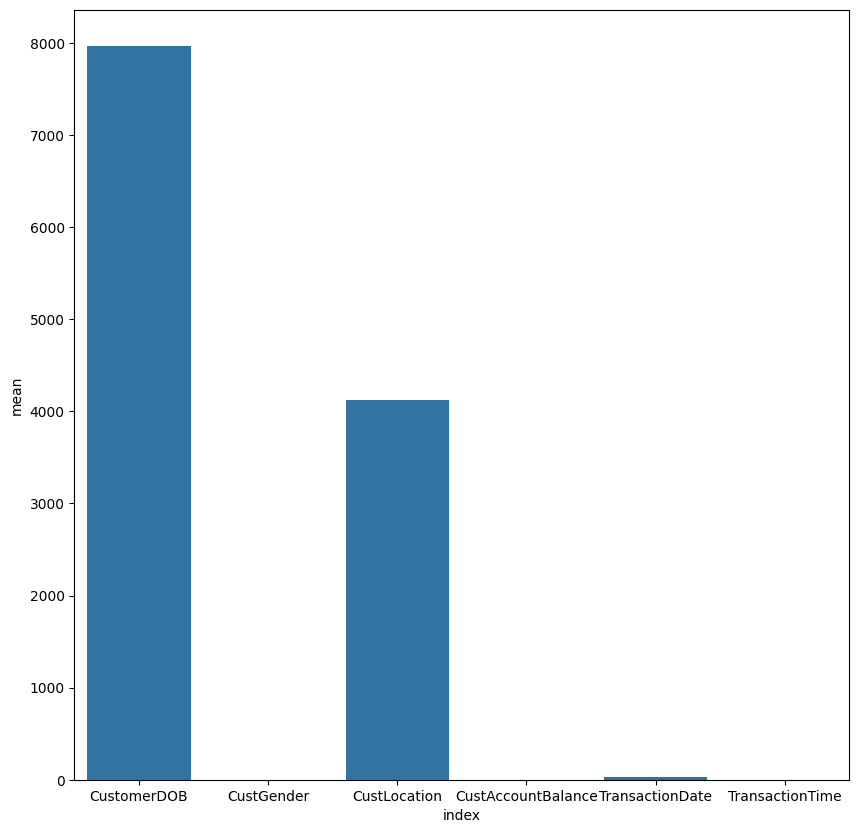

In [27]:
import seaborn as sns
plt.figure(figsize=(10,10))
sns.barplot(x='index',y='mean',data = q_mean)

<Axes: >

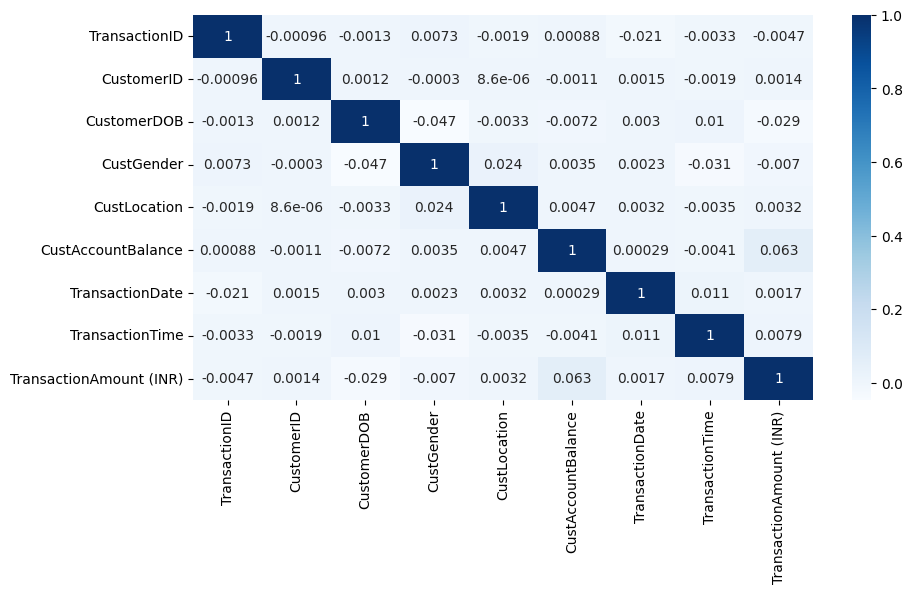

In [34]:
corr = df.corr()
plt.figure(figsize=(10,5))
sns.heatmap(corr,annot=True,cmap='Blues')

In [35]:
X = df.iloc[:,2:8]
pca = PCA(n_components=2,random_state=42)
X_pca = pca.fit_transform(X)

In [36]:
pca

PCA(n_components=2, random_state=42)

In [37]:
X_pca

array([[-7229.81750948,  -552.85380186],
       [ 6117.04395989,  -466.01031053],
       [ 2447.03491028,  1147.16126497],
       ...,
       [-2366.46857447,  -735.80170927],
       [ 5427.82810335,  5021.71626774],
       [ 6687.32670198,  2606.05646635]])

In [38]:
pca.explained_variance_ratio_.cumsum()[0]

np.float64(0.8328905011271505)

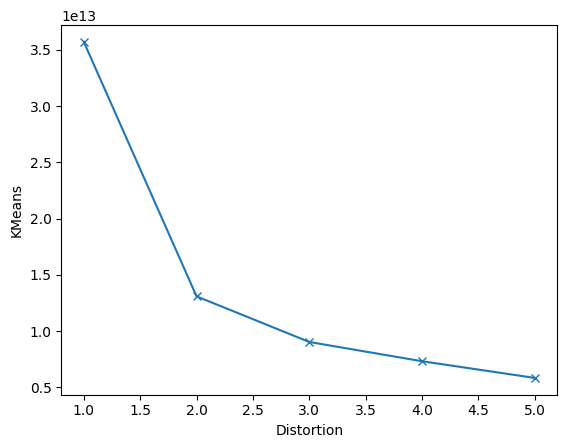

In [41]:
distortion = []
for i in range(1,6):
  km = KMeans(n_clusters=i,init = 'k-means++',random_state=42,n_init=10)
  km.fit(X_pca)
  distortion.append(km.inertia_)
plt.plot(range(1,6),distortion,marker = 'x')
plt.xlabel("Distortion")
plt.ylabel("KMeans")
plt.show()

In [42]:
model = KMeans(n_clusters=3,init='k-means++',random_state=42,n_init=10)
model.fit(X_pca)
y = model.predict(X_pca)

In [45]:
y

array([1, 2, 0, ..., 0, 2, 2], dtype=int32)

In [48]:
X_pca[y==0,0]

array([ 2447.03491028,  1450.31256746,  2351.0350778 , ...,
       -2034.58864971,  -808.63142393, -2366.46857447])

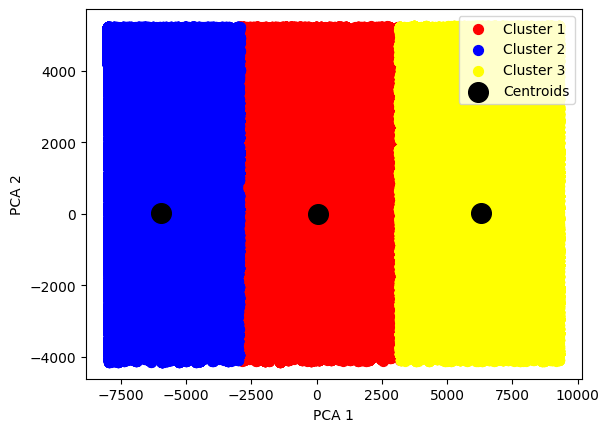

In [46]:
plt.scatter(X_pca[y==0,0],X_pca[y==0,1],s=50,c='red',label = 'Cluster 1')
plt.scatter(X_pca[y==1,0],X_pca[y==1,1],s=50,c='blue',label = 'Cluster 2')
plt.scatter(X_pca[y==2,0],X_pca[y==2,1],s=50,c='yellow',label='Cluster 3')
plt.scatter(model.cluster_centers_[:,0],model.cluster_centers_[:,1],s=200,c='black',label = 'Centroids')
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()
plt.show()